In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, LassoCV, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler,RobustScaler, MinMaxScaler, QuantileTransformer
from xgboost import XGBRegressor

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

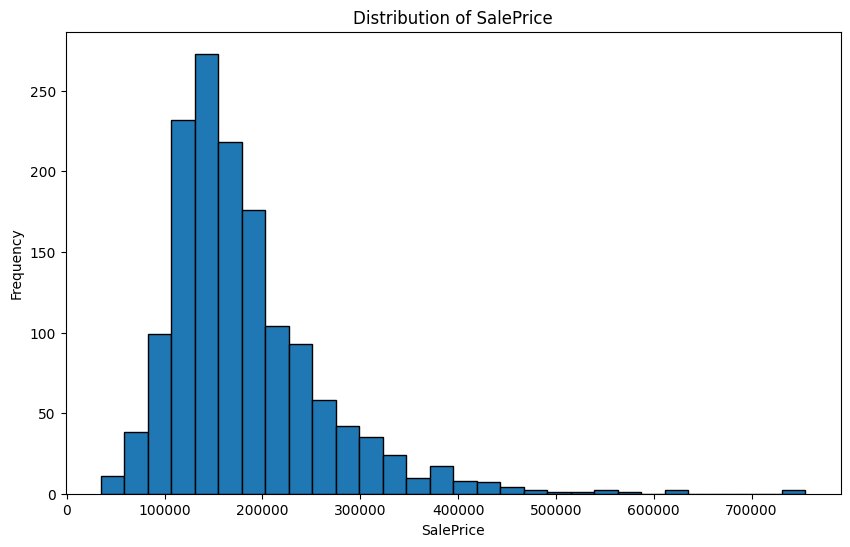

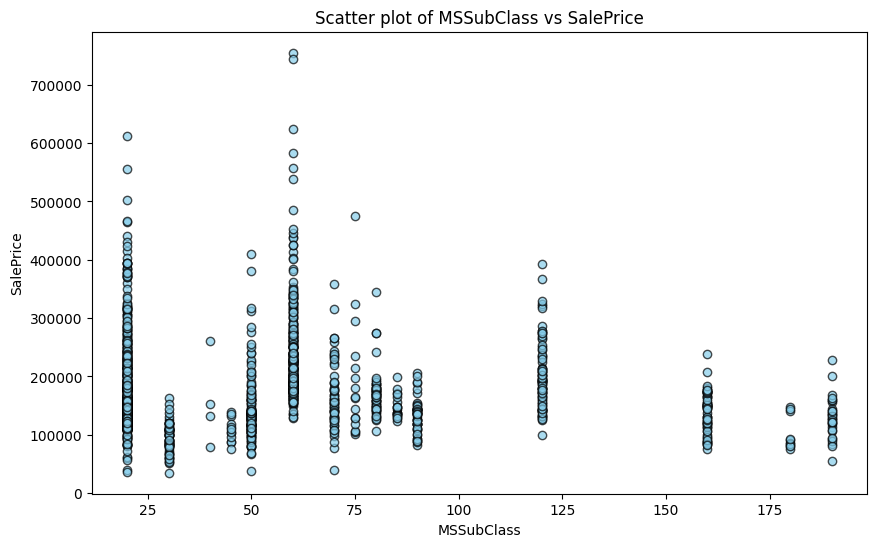

In [3]:
df = pd.read_csv("train.csv")
# df.describe()
df.info(max_cols=None)

plt.figure(figsize=(10, 6))
plt.hist(df['SalePrice'], bins=30, edgecolor='black')
plt.title('Distribution of SalePrice')
plt.xlabel('SalePrice')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(10, 6))
plt.scatter(df['MSSubClass'], df['SalePrice'], alpha=0.7, color='skyblue', edgecolors='k')
plt.title('Scatter plot of MSSubClass vs SalePrice')
plt.xlabel('MSSubClass')
plt.ylabel('SalePrice')
plt.show()

In [4]:
df1 = pd.read_csv("test.csv")


In [5]:
def preprocess_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    
    df = df.drop(['Alley', 'PoolQC', 'MiscFeature'], axis=1, errors='ignore')
    for col in df.columns:
        if df[col].isnull().any():
            if df[col].dtype == 'object':
                df[col] = df[col].fillna(df[col].mode()[0])
            else:
                df[col] = df[col].fillna(df[col].median())


    column_quality_mappings = {
        'ExterQual': {'Ex': 10, 'Gd': 8, 'TA': 6, 'Fa': 4, 'Po': 2, 'NA': 0},
        'ExterCond': {'Ex': 10, 'Gd': 8, 'TA': 6, 'Fa': 4, 'Po': 2, 'NA': 0},
        'BsmtQual': {'Ex': 10, 'Gd': 8, 'TA': 6, 'Fa': 4, 'Po': 2, 'NA': 0},
        'BsmtCond': {'Ex': 10, 'Gd': 8, 'TA': 6, 'Fa': 4, 'Po': 2, 'NA': 0},
        'HeatingQC': {'Ex': 10, 'Gd': 8, 'TA': 6, 'Fa': 4, 'Po': 2, 'NA': 0},
        'KitchenQual': {'Ex': 10, 'Gd': 8, 'TA': 6, 'Fa': 4, 'Po': 2, 'NA': 0},
        'FireplaceQu': {'Ex': 10, 'Gd': 8, 'TA': 6, 'Fa': 4, 'Po': 2, 'NA': 0},
        'GarageQual': {'Ex': 10, 'Gd': 8, 'TA': 6, 'Fa': 4, 'Po': 2, 'NA': 0},
        'GarageCond': {'Ex': 10, 'Gd': 8, 'TA': 6, 'Fa': 4, 'Po': 2, 'NA': 0},
        'LotShape': {'Reg': 3, 'IR1': 2, 'IR2': 1, 'IR3': 0, 'NA': 0},
        'LandContour': {'Lvl': 3, 'Bnk': 2, 'HLS': 1, 'Low': 0, 'NA': 0},
        'Utilities': {'AllPub': 4, 'NoSewr': 3, 'NoSeWa': 2, 'ELO': 1, 'NA': 0},
        'LandSlope': {'Gtl': 3, 'Mod': 2, 'Sev': 1, 'NA': 0},
        'BsmtFinType1': {'GLQ': 12, 'ALQ': 10, 'BLQ': 8, 'Rec': 6, 'LwQ': 4, 'Unf': 2, 'NA': 0},
        'BsmtFinType2': {'GLQ': 12, 'ALQ': 10, 'BLQ': 8, 'Rec': 6, 'LwQ': 4, 'Unf': 2, 'NA': 0},
        'CentralAir': {'N': 0, 'Y': 1, 'NA': 0},
        'Functional': {'Typ': 7, 'Min1': 6, 'Min2': 5, 'Mod': 4, 'Maj1': 3, 'Maj2': 2, 'Sev': 1, 'Sal': 0, 'NA': 0},
        'GarageFinish': {'Fin': 10, 'RFn': 7, 'Unf': 4, 'NA': 0},
        'PavedDrive': {'Y': 2, 'P': 1, 'N': 0, 'NA': 0},
        'BsmtExposure': {'Gd': 4, 'Av': 3, 'Mn': 2, 'No': 1, 'NA': 0},
    }

    for col, mapping in column_quality_mappings.items():
        if col in df.columns:
            df[col] = df[col].map(mapping).fillna(0)

    
    df['total_area'] = df['1stFlrSF'] + df['2ndFlrSF'] + df['TotalBsmtSF']
    df['house_age'] = (df['YrSold'] - df['YearBuilt'] + 1).clip(lower=1)
    df['garage_size_per_car'] = (df['GarageArea'] / df['GarageCars'].replace(0, float('inf'))) * df['GarageQual']
    df['kitchen'] = df['KitchenAbvGr'] * df['KitchenQual']
    df['total_bathroom'] = (df['FullBath'] + df['BsmtFullBath']) + 0.5 * (df['HalfBath'] + df['BsmtHalfBath'])
    df['house'] = df['total_area']*df['OverallCond']/df['house_age'] + df['kitchen']
        
    return df

encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)
column_mapping = [
    'MSZoning', 'LotConfig', 'Neighborhood', 'Condition1', 'Condition2',
    'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd',
    'MasVnrType', 'Foundation', 'Heating', 'Electrical', 'GarageType',
    'Fence', 'SaleType', 'SaleCondition', 'Street'
]

df_processed = preprocess_dataframe(df)
categorical_train = pd.DataFrame(
    encoder.fit_transform(df_processed[column_mapping]),
    columns=encoder.get_feature_names_out(column_mapping),
    index=df_processed.index
)
df = pd.concat([df_processed.drop(columns=column_mapping), categorical_train], axis=1)

X_test_processed = preprocess_dataframe(df1)
categorical_test = pd.DataFrame(
    encoder.transform(X_test_processed[column_mapping]),
    columns=encoder.get_feature_names_out(column_mapping),
    index=X_test_processed.index
)
X_test = pd.concat([X_test_processed.drop(columns=column_mapping), categorical_test], axis=1)

# Save train
df.to_csv("train_processed.csv", index=False)
X_test.to_csv("test_processed.csv", index=False)


c:\Users\shari\miniconda3\envs\python3\Lib\site-packages\sklearn\preprocessing\_encoders.py:975: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


C:\Users\shari\AppData\Local\Temp\ipykernel_35312\586488079.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correlations_subset.values, y=correlations_subset.index, palette='coolwarm')


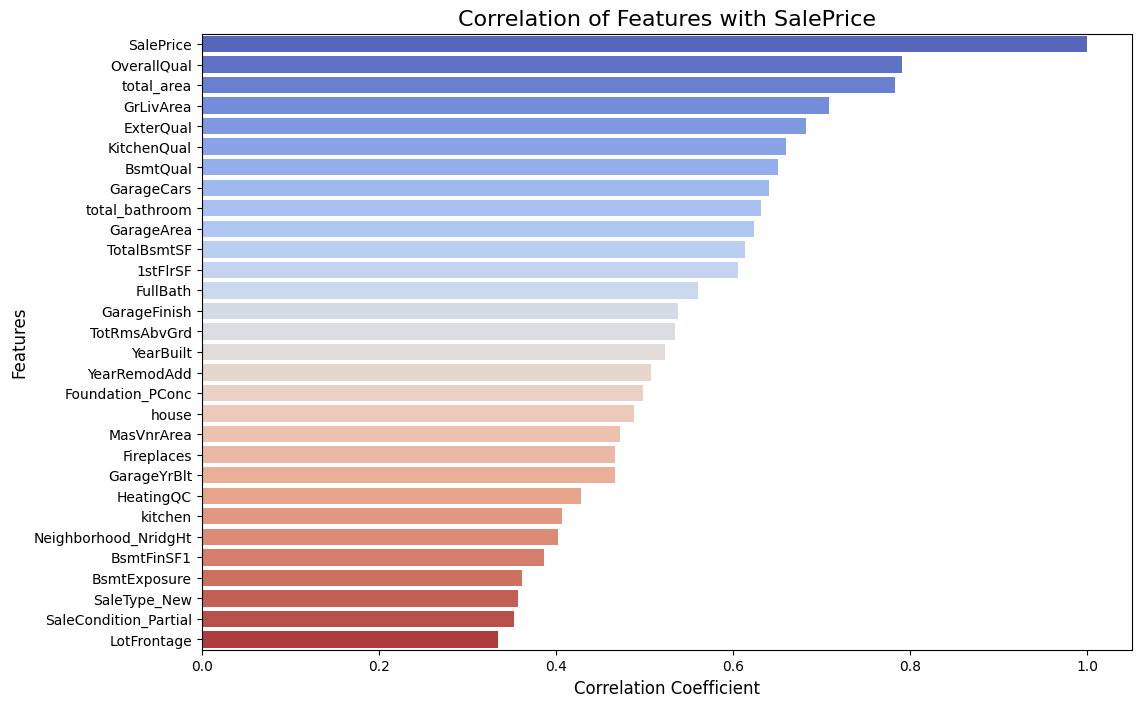

In [6]:
correlation_matrix = df.corr()

start_index = 0
page_size = 30
end_index = start_index + page_size

correlations = correlation_matrix['SalePrice'].sort_values(ascending=False)
correlations_subset = correlations[start_index:end_index]
plt.figure(figsize=(12, 8))
sns.barplot(x=correlations_subset.values, y=correlations_subset.index, palette='coolwarm')
plt.title(f'Correlation of Features with SalePrice', fontsize=16)
# Add labels to the axes.
plt.xlabel('Correlation Coefficient', fontsize=12)
plt.ylabel('Features', fontsize=12)

# Add a vertical line at x=0 for a clear baseline.
plt.axvline(x=0, color='gray', linestyle='--')

# Display the plot.
plt.show()


In [7]:
X = df.drop(columns=['SalePrice'])
Y = df['SalePrice']

def rmse_log_error(y_true, y_pred):
    y_pred = np.maximum(y_pred, 0)
    return np.sqrt(mean_squared_error(np.log1p(y_true), np.log1p(y_pred)))

rmse_scorer = make_scorer(rmse_log_error, greater_is_better=False)

In [10]:
model1 = ElasticNet()

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', model1)
])

param_grid = {
    'scaler': [StandardScaler(), RobustScaler(), MinMaxScaler()],
    'model__fit_intercept': [True, False],
    'model__max_iter': [1000, 2000],
    'model__tol': [1e-3, 1e-2, 1e-1],
    'model__selection': ['cyclic', 'random'],
    'model__precompute': [True, False]
}

grid_search = GridSearchCV(pipe, param_grid, scoring=rmse_scorer, cv=2, verbose=1, n_jobs=-1)
grid_search.fit(X, Y)

print("Best parameters found: ", grid_search.best_params_)
print("Best score (negative MSE): ", grid_search.best_score_)

Fitting 2 folds for each of 144 candidates, totalling 288 fits
Best parameters found:  {'model__fit_intercept': True, 'model__max_iter': 1000, 'model__precompute': False, 'model__selection': 'random', 'model__tol': 0.01, 'scaler': StandardScaler()}
Best score (negative MSE):  -0.154396376828788


In [11]:
model3 = RandomForestRegressor()

pipe2 = Pipeline([
    ('model', model3)
])

param_grid2 = {
    'model__n_estimators': [470, 490],
    'model__max_depth': [None, 30, 31, 35, 37],
    'model__min_samples_split': [2, 5],
    'model__min_samples_leaf': [1, 2, 4],
    'model__max_features': ['sqrt', 'log2'],
}

grid_search2 = GridSearchCV(pipe2, param_grid2, scoring=rmse_scorer, cv=3, verbose=1, n_jobs=-1)
grid_search2.fit(X, Y)

print("Best parameters found for Random Forest: ", grid_search2.best_params_)
print("Best score (negative MSE) for Random Forest: ", grid_search2.best_score_)

Fitting 3 folds for each of 120 candidates, totalling 360 fits
Best parameters found for Random Forest:  {'model__max_depth': 30, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 490}
Best score (negative MSE) for Random Forest:  -0.14195596323772103


In [12]:
model4 = XGBRegressor(device = 'cuda')
from sklearn.model_selection import RandomizedSearchCV

pipe3 = Pipeline([
    ('scaler', StandardScaler()),
    ('model', model4)
])

param_grid3 = {
    'scaler': [StandardScaler(), RobustScaler(), MinMaxScaler()],
    'model__n_estimators': [2000],
    'model__max_depth': [5, 3],
    'model__learning_rate': [0.005],
    'model__subsample': [0.9],
    'model__colsample_bytree': [0.8],
}

random_search3 = RandomizedSearchCV(
    estimator=pipe3,
    param_distributions=param_grid3,
    n_iter=5,
    scoring=rmse_scorer,
    cv=2,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

random_search3.fit(X, Y)

print("Best parameters found for XGBoost: ", random_search3.best_params_)
print("Best score (negative MSE) for XGBoost: ", random_search3.best_score_)

Fitting 2 folds for each of 5 candidates, totalling 10 fits
Best parameters found for XGBoost:  {'scaler': StandardScaler(), 'model__subsample': 0.9, 'model__n_estimators': 2000, 'model__max_depth': 5, 'model__learning_rate': 0.005, 'model__colsample_bytree': 0.8}
Best score (negative MSE) for XGBoost:  -0.12828715288584763


In [19]:
from sklearn.svm import SVR

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', SVR())
])

param_grid = {
    'scaler': [MinMaxScaler()],
    'model__C': [2650],
    'model__epsilon': [0.2, 0.3],
    'model__kernel': ['linear', 'poly', 'rbf', 'sigmoid'],
    'model__degree': [2, 3, 4],
    'model__gamma': ['scale', 'auto']
}

grid_search4 = GridSearchCV(pipe, param_grid, scoring=rmse_scorer, cv=2, verbose=1, n_jobs=-1)
grid_search4.fit(X, Y)

print("Best parameters found for SVM: ", grid_search4.best_params_)
print("Best score (negative MSE) for SVM: ", grid_search4.best_score_)

Fitting 2 folds for each of 48 candidates, totalling 96 fits
Best parameters found for SVM:  {'model__C': 2650, 'model__degree': 2, 'model__epsilon': 0.3, 'model__gamma': 'scale', 'model__kernel': 'linear', 'scaler': MinMaxScaler()}
Best score (negative MSE) for SVM:  -0.1448856706892831


In [15]:
# # Find the maximum value in the DataFrame
# max_value = X_test['house'].max().max()

# col = X_test['house'].idxmax()
# print(X_test['YearBuilt'][col])

# print(f"Largest value: {max_value}")

predictions1 = grid_search.predict(X_test)
predictions3 = grid_search2.predict(X_test)
predictions4 = random_search3.predict(X_test)
predictions5 = grid_search4.predict(X_test)

c:\Users\shari\miniconda3\envs\python3\Lib\site-packages\xgboost\core.py:729: UserWarning: [19:34:08] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


In [ ]:
# Stack them
# stack = StackingRegressor(
#     estimators=[
#         ('model1', best_model1),
#         ('model3', best_model3),
#         ('model4', best_model4),
#         ('model5', best_model5)
#     ],
#     final_estimator=XGBRegressor(n_estimators=1500, learning_rate=0.001, max_depth=5, subsample=0.8, colsample_bytree=0.8, device='cuda'),
#     cv=2,
#     n_jobs=-1
# )

# stack.fit(X, Y)
# stack_predictions = stack.predict(X_test)

rmse1 = np.sqrt(-grid_search.best_score_)
rmse2 = np.sqrt(-grid_search2.best_score_)
rmse3 = np.sqrt(-random_search3.best_score_)
rmse4 = np.sqrt(-grid_search4.best_score_)

weights = np.array([1/rmse1, 1/rmse2, 1/rmse3, 1/rmse4])
weights /= weights.sum()

stack_predictions = (weights[0] * grid_search.predict(X_test) +
                    weights[1] * grid_search2.predict(X_test) +
                    weights[2] * random_search3.predict(X_test) +
                    weights[3] * grid_search4.predict(X_test))

# Save submission
prediction_df = pd.DataFrame({
    'Id': df1['Id'],
    'SalePrice': stack_predictions
})
prediction_df.to_csv('submission.csv', index=False)
print(prediction_df.head(10))


     Id      SalePrice
0  1461  116942.710490
1  1462  160687.521262
2  1463  181743.277973
3  1464  190445.374183
4  1465  194104.913422
5  1466  173504.438108
6  1467  172778.261264
7  1468  168778.362332
8  1469  184986.912038
9  1470  122911.499111
